In [ ]:
# importazione dataset da Github (usato dataset Kaggle)
URL = "https://raw.githubusercontent.com/andrealuigipala-del/MLOps_Final_Project/refs/heads/main/Twitter_Data.csv"
data = pd.read_csv(URL)
df = data.dropna(subset=["clean_text", "category"]) # pulizia dataset da righe / colonne vuote mediante eliminazione righe

In [ ]:
data.isna().sum(), df.isna().sum() # visualizzazione NaN e dataset pulito

(clean_text    4
 category      7
 dtype: int64,
 clean_text    0
 category      0
 dtype: int64)

In [ ]:
data.shape, df.shape # check dimensionale

((162980, 2), (162969, 2))

In [ ]:
!pip install transformers

In [ ]:
from transformers import pipeline
model_path = "cardiffnlp/twitter-roberta-base-sentiment-latest"
sentiment_task = pipeline("sentiment-analysis", model=model_path, tokenizer=model_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
sentiment_task("what!")

[{'label': 'neutral', 'score': 0.5101788640022278}]

In [ ]:
df["category"] = df["category"] - df["category"].min()

/tmp/ipykernel_6765/3890886110.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["category"] = df["category"] - df["category"].min()


In [ ]:
lenght = 10000

In [ ]:
X = df["clean_text"].head(lenght).tolist()
y = df["category"].head(lenght).tolist()

In [ ]:
np.array(X).shape

(10000,)

In [ ]:
y_pred = sentiment_task(X)

In [ ]:
# Mappa numeri → stringhe
num2label = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Converti y numerico in stringhe
y_labels = [num2label[i] for i in y]

# Estrai etichette predette dalla pipeline
y_pred_labels = [pred['label'] for pred in y_pred]

# Ora puoi usare classification_report
from sklearn.metrics import classification_report
print(classification_report(y_labels, y_pred_labels))


              precision    recall  f1-score   support

    negative       0.40      0.67      0.50      2370
     neutral       0.47      0.64      0.55      3477
    positive       0.72      0.22      0.34      4153

    accuracy                           0.48     10000
   macro avg       0.53      0.51      0.46     10000
weighted avg       0.56      0.48      0.45     10000



In [ ]:
from datasets import Dataset
from sklearn.model_selection import train_test_split

# Trasforma in Hugging Face Dataset
dataset = Dataset.from_pandas(df)

dataset = dataset.train_test_split(test_size=0.2, seed=42)

# Estrai train e validation
train_dataset = dataset["train"]
val_dataset = dataset["test"]

# Verifica
print(f"Numero esempi train: {len(train_dataset)}")
print(f"Numero esempi validation: {len(val_dataset)}")

Numero esempi train: 130375
Numero esempi validation: 32594


In [ ]:
# tokenizzazione

from transformers import AutoTokenizer

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Funzione di tokenizzazione
def tokenize(batch):
    return tokenizer(batch["clean_text"], padding="max_length", truncation=True, max_length=128)

# Applica la tokenizzazione
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

# Rinominare la colonna label come 'labels' (richiesto dal Trainer)
train_dataset = train_dataset.rename_column("category", "labels")
val_dataset = val_dataset.rename_column("category", "labels")

# Imposta il formato PyTorch
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Controllo
print(train_dataset[0])

Map:   0%|          | 0/130375 [00:00<?, ? examples/s]

Map:   0%|          | 0/32594 [00:00<?, ? examples/s]

{'labels': tensor(2.), 'input_ids': tensor([    0, 50118, 25407,  3017,  9473,   493,    61,    21,   656,   576,
         1149, 19456,   352,  1416, 20191,  7071,  7791,   223, 11134,   118,
          213, 26390,    31,  4047, 16136, 16018,  9799,   709, 11606, 10335,
         4042,  1616,  9499,    92, 16889,     9, 27013, 50118,   705,   811,
        12705,  1115,     2,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,

# CHATGPT

In [ ]:
!pip install transformers datasets evaluate

In [ ]:
!pip install -U transformers

In [ ]:
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

# Controlla GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Parametri principali
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 2  # Puoi aumentare per più accuratezza

Device: cuda


In [ ]:
# X = lista/testi, y = lista/etichette 0,1,2
dataset_dict = {"clean_text": X, "labels": y}
dataset = Dataset.from_dict(dataset_dict)

# Split 80/20 train/val
split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split['train']
val_dataset = split['test']

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["clean_text"], padding="max_length", truncation=True, max_length=MAX_LENGTH)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,  # negative, neutral, positive
    problem_type="single_label_classification"  # ← qui aggiungi questa riga
)
model.to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    f1 = metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"f1": f1}

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=50,
    save_strategy="epoch",
    report_to="none"
)

In [ ]:
import torch

def convert_labels_to_long(batch):
    # Se labels è un tensore
    if isinstance(batch["labels"], torch.Tensor):
        batch["labels"] = batch["labels"].long()
    else:
        # Se è lista, converte in tensore long
        batch["labels"] = torch.tensor(batch["labels"], dtype=torch.long)
    return batch

train_dataset = train_dataset.map(convert_labels_to_long)
val_dataset = val_dataset.map(convert_labels_to_long)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
import torch

# Converte la colonna labels in tensore long
def fix_labels(batch):
    batch["labels"] = torch.tensor(batch["labels"], dtype=torch.long)
    return batch

train_dataset = train_dataset.map(fix_labels)
val_dataset = val_dataset.map(fix_labels)

# Controllo veloce
print(train_dataset[0]["labels"].dtype)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

/tmp/ipykernel_6765/1489686421.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.long)


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

torch.float32


In [ ]:
print(type(train_dataset[0]["labels"]))
print(train_dataset[0]["labels"])

<class 'torch.Tensor'>
tensor(2.)


In [ ]:
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Forza labels a long (int64)
train_dataset = train_dataset.map(lambda x: {"labels": int(x["labels"])})
val_dataset   = val_dataset.map(lambda x: {"labels": int(x["labels"])})

# Riapplica formato torch (IMPORTANTE)
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Controllo finale
print(train_dataset[0]["labels"], train_dataset[0]["labels"].dtype)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

tensor(2.) torch.float32


In [ ]:
from transformers import Trainer

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels").long()  # ← QUI la conversione corretta
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            labels=labels
        )
        loss = outputs.loss
        return (loss, outputs) if return_outputs else loss

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)


In [ ]:
# import torch

# # Forza CPU
# device = torch.device("cpu")
# model.to(device)

# # Poi lancia il training
# trainer.train()

In [ ]:
predictions = trainer.predict(val_dataset)

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.37      0.65      0.47       442
         1.0       0.48      0.65      0.55       721
         2.0       0.75      0.23      0.35       837

    accuracy                           0.47      2000
   macro avg       0.53      0.51      0.46      2000
weighted avg       0.57      0.47      0.45      2000



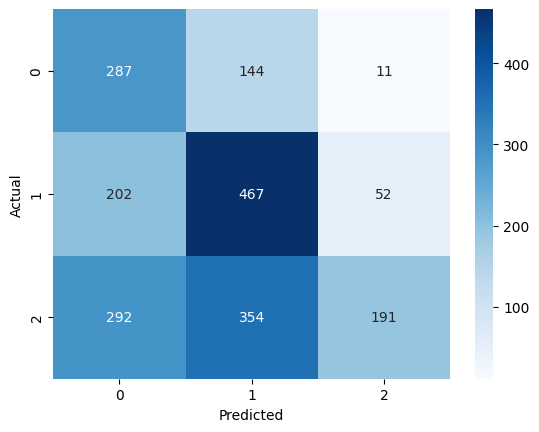

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
trainer.save_model("model_final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
total = len(train_dataset) + len(val_dataset)
print("Totale dataset:", total)

Totale dataset: 10000


In [ ]:
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Totale:", len(train_dataset) + len(val_dataset))

Train: 8000
Validation: 2000
Totale: 10000


# Notebook comunicante con github

In [ ]:
!pip install transformers datasets torch pandas scikit-learn

In [ ]:
!git clone https://github.com/andrealuigipala-del/MLOps_sentiment_project.git /content/MLOps_sentiment_project

fatal: destination path '/content/MLOps_sentiment_project' already exists and is not an empty directory.


In [1]:
!pwd

/content


In [21]:
%cd ..
%cd content/MLOps_sentiment_project/

/
/content/MLOps_sentiment_project


In [23]:
from scripts.preprocess import load_dataset
from scripts.train import fine_tune_model
from scripts.evaluate_and_save import evaluate_model

In [ ]:
from scripts import preprocess, train, evaluate_and_save

print(dir(preprocess))

ImportError: cannot import name 'preprocess' from 'scripts' (/content/MLOps_sentiment_project/scripts/__init__.py)

In [ ]:
!ls /content/MLOps_sentiment_project

data  notebooks  ReadMe.md  requirements.txt  scripts


In [ ]:
!touch /content/MLOps_sentiment_project/scripts/__init__.py

In [ ]:
import sys
sys.path.append("/content/MLOps_sentiment_project")

In [ ]:
from scripts.preprocess import load_dataset
from scripts.train import fine_tune_model
from scripts.evaluate_and_save import evaluate_model

ModuleNotFoundError: No module named 'preprocess'

In [ ]:
url = "https://raw.githubusercontent.com/andrealuigipala-del/MLOps_Final_Project/refs/heads/main/Twitter_Data.csv"

X_train, X_test, y_train, y_test = load_dataset(url)

print(len(X_train), len(X_test))

In [ ]:
trainer, model, tokenizer = fine_tune_model(
    X_train[:5000], y_train[:5000],
    X_test[:1000], y_test[:1000]
)

In [ ]:
evaluate_model("./results", url)

In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", model="./results")

texts = [
    "MachineInnovators is amazing!",
    "This service is terrible",
    "It's okay, nothing special"
]

predictions = classifier(texts)

for t, p in zip(texts, predictions):
    print(t, "->", p)

In [ ]:
# Questo progetto utilizza una pipeline MLOps con:
# - preprocessing dati
# - fine-tuning modello HuggingFace
# - valutazione automatica
# - deploy su HuggingFace Hub
# - pipeline CI/CD tramite GitHub Actions

In [ ]:
import time
time.sleep(3600)